# Parallel processing in R in NaaVRE workflows
## “Batch” splitting for processing a larger number of items

When parallel processing a large number of items, creating a separate process for each individual item can lead to significant overhead. This is because the workflow engine must constantly start and stop new processes, which wastes time and computing resources. 

To solve this, a more efficient approach is to group the items into batches and then process each batch in a single parallel instance. This way, instead of running a separate process for every single item, you run one process for an entire batch. This minimizes the overhead, allowing you to get more work done with the same resources.

This batch processing can be done using the following cells:

- A "Preprocessor" that calculates the batch size and provides the data to process.
- An "Index generator" that generates a list of start indices of batches.
- A "Processor" that processes the batches using `purrr::map`. The execution of this cell is parallelized, so applying this batch processing strategy is useful if this step takes up a significant amount of time.
- A "Data merger" that puts the processed items into a simple list.

In the workflow context, we can introduce a splitter between "Index generator" and "Processor" and a merger between "Processor" and "Data merger".

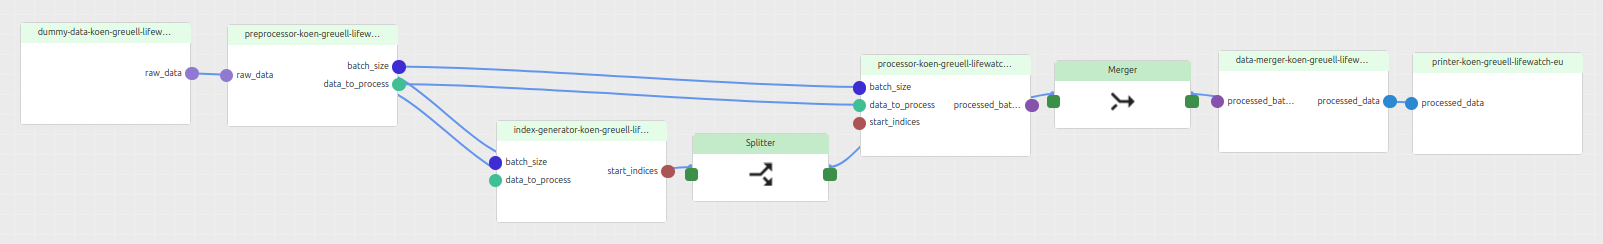

As a result, multiple instances of the "Processor" will be crearted. 

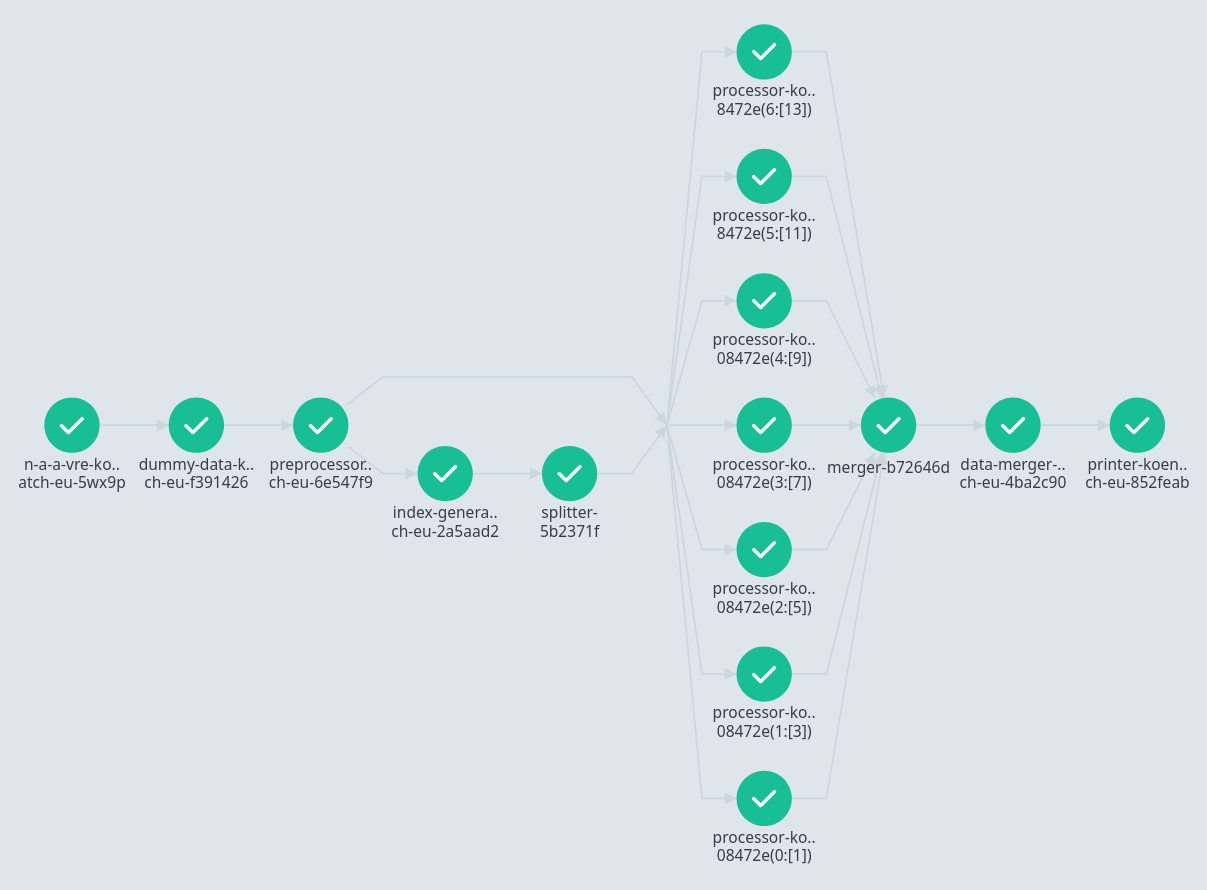

### Cell: parameters
This cell defines the maximum number of batches that can be created. 

In [14]:
# (do not containerize!) parameters
param_max_batch_count <- 10

In [8]:
# dummy data
raw_data <- list()
raw_data <- c("0000001", "0001011", "0010101", "0011111", "0101001", "0110011", "0111101", "01000111", "1010001", "1011011", "1100101", "1101111", "1111001")
cli::cli_text("{.arg raw_data}: {raw_data}")

`raw_data`: 0000001, 0001011, 0010101, 0011111, 0101001, 0110011, 0111101,
01000111, 1010001, 1011011, 1100101, 1101111, and 1111001



### Cell: Preprocessor
Creates a variable named `data_to_process` containing the data that will be processed in parallel and a variable `batch_size` that determines the maximum number of items that should be combined into a batch.

This implementation will only increase the number of batches (up to the defined maximum `param_max_batch_count`) if it results in a smaller `batch_size`. The batch size is the largest number of items processed in any single batch. By minimizing this size, you can optimize processing time.

Let's illustrate with a few examples:
- Scenario 1: You have 13 items and a `param_max_batch_count` of 10. 13 items / 10 batches = 1.3 items per batch on average. Since items must be whole, the largest batch size will be 2.
    With a max batch size of 2, the total number of batches needed is 13 items / 2 items per batch = 6.5. This rounds up to 7 batches, which is less than the max_batch_count. So, 7 batches will be used.
- Scenario 2: You have 13 items and a `param_max_batch_count` of 16. In this case the number of batches is limited by the total number of items. So, the system will create 13 batches, with each batch containing just one item.

In [17]:
# preprocessor
# ---
# NaaVRE:
#  cell:
#   params:
#    - param_max_batch_count : Integer
# ...
data_to_process <- list()
data_to_process <- raw_data
cli::cli_text("{.arg data_to_process}: {data_to_process}")
########################## start boilerplate code for batch processing ###############################
batch_size <- 0
batch_size <- ceiling(length(data_to_process)/param_max_batch_count)
cli::cli_text("{.arg batch_size}: {batch_size}")
########################## end boilerplate code for batch processing #################################

`data_to_process`: 0000001, 0001011, 0010101, 0011111, 0101001, 0110011,
0111101, 01000111, 1010001, 1011011, 1100101, 1101111, and 1111001

`batch_size`: 2



### Cell: Index generator
Creates indexes for the start of each batch. This results in a list of indexes of a length equal to the number of instances to be created. We will apply the splitter to the list `start_indices`.

In [18]:
# index generator
# ---
# NaaVRE:
#  cell:
#   params:
#    - param_max_batch_count : Integer
# ...
########################## start boilerplate code for batch processing ###############################
start_indices <- list(1)
if (param_max_batch_count > 1) {
    start_indices <- seq(1, length(data_to_process), by = batch_size) 
}
cli::cli_text("{.arg start_indices}: {start_indices}")
########################## end boilerplate code for batch processing #################################

`start_indices`: 1, 3, 5, 7, 9, 11, and 13



### Cell: Processor
Processes the data by applying a function defined in `perform_custom_operation` to each item.
By mapping to the start indices, the data processor can process all data sequentially, or in parallel by using the splitter in a workflow.

In [19]:
# processor

# example function applied to all items
convert_binary_to_int <- function(binary_string) {
  return(strtoi(binary_string, base = 2))
}

# wrapper function. Return your own function here
perform_custom_operation <- function(item) {
  return(convert_binary_to_int(item))
}

########################## start boilerplate code for batch processing ###############################
processed_batches <- list()
processed_batches <- purrr::map(start_indices, function(i) {
  end_index <- i + batch_size - 1
  if (end_index > length(data_to_process)) {
    end_index <- length(data_to_process)
  }
  current_batch <- data_to_process[i:end_index]
  calculated_batch <- purrr::map(current_batch, perform_custom_operation)
  length_calculated_batch <- length(calculated_batch)
  one_dimensional_vector <- unlist(calculated_batch)
  return(one_dimensional_vector)
})
cli::cli_text("{.arg processed_batches}: {processed_batches}")
########################## end boilerplate code for batch processing #################################

`processed_batches`: c(1, 11), c(21, 31), c(41, 51), c(61, 71), c(81, 91),
c(101, 111), and 121



### Cell: Data merger
The output of the data processor is a vector containing vectors. The merger flattens the processed data into a simple list.

In [22]:
# data merger
########################## start boilerplate code for batch processing ###############################
processed_data <- list()
processed_data <- unlist(processed_batches)
cli::cli_text("{.arg processed_data}: {processed_data}")
########################## end boilerplate code for batch processing #################################

`processed_data`: 1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 111, and 121



In [13]:
# printer
print(processed_data)

 [1]   1  11  21  31  41  51  61  71  81  91 101 111 121
